<a href="https://colab.research.google.com/github/kaushikdas/InterestingCodes/blob/master/C_C%2B%2B/Adv_Features_of_C%2B%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6. Additional Techniques

## 6.1. Multithreading

There was a time in early C++ where threading wasn't actually defined in the standard library. We'd have to use an operating system APIs (like the Linux APIs or the Windows APIs), which is obviously *not portable* across different operating systems. But nowadays, there is a standard thread in API and C++.

- `thread` header file

### 6.1.1. Creating thread using function

- To create a new thread and await its completion:

```cpp
#include <iostream>
#include <thread>   // <--- defines std::thread

void myfunc1 () {
  std :: cout << "Doing some work" << std :: endl;
}

int main () {
  // >>>>>>>
  std::thread t1(myfunc1);
  // ...
  // ...
  t1.join();
  // <<<<<<<
}
```

- You create a thread object and you give it a callable object ( for example, the name of a function&mdash;`myfunc1` in this case). - When you create a thread object, the *thread object creates a system thread* underneath the surface and executes your function *on that thread*.
  - So this function would be doing some kind of background work probably, *at the same time as the main thread continues to execute*.
  
- So if your main thread is going to potentially finish before the other thread, you can say other thread dot `join` When you call `t1.join()`, the main thread waits for the thread `t1` to finish executing before it (main thread) continues. So, the main thread pauses until t1 completes its work, ensuring proper synchronization between threads. It's a very simple way of defining like a rendezvous.

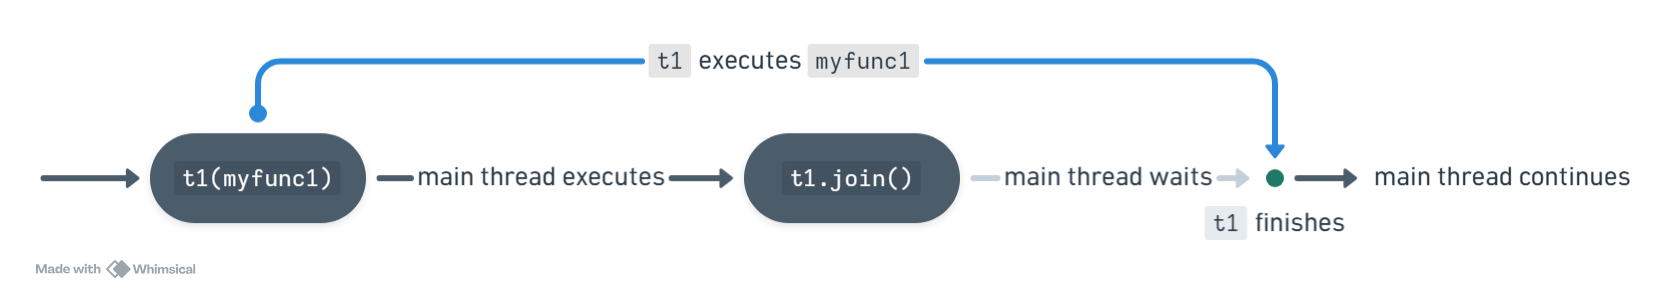

### 6.1.2. Creating thread using **lambda**

* The `std::thread` constructor allows you to use a
lambda to specify the code to run in the thread

```cpp
#include <thread>
#include <iostream>

int main() {
  std::thread t1([] {
    std :: cout << "Hello from another thread!" << std :: endl;
  });

  //...

  t1.join();
}
```

> **Passing parameters to thread function**

* For functions: https://share.google/aimode/dr6RhUb0HSrrYf3tO

```cpp
// Example
#include <iostream>
#include <thread>

// Define a normal function
void printSum(int a, int b) {
    std::cout << "Sum: " << (a + b) << "\n";
}

int main() {
    int x = 10;
    int y = 20;

    // Pass the function pointer followed by the arguments
    std::thread t(printSum, x, y);

    t.join();
    return 0;
}
```
* For lambdas: https://share.google/aimode/dr6RhUb0HSrrYf3tO

In [ ]:
%%writefile pass_param_to_thrd_lmda.cpp

#include <iostream>
#include <thread>

int main() {
    int value = 42;

    std::cout << "From main\n";

    // The lambda accepts an int.
    // 'value' is passed as the trailing constructor argument.
    std::thread t([](int x) {
      std::cout << "From thread t: "
                << "Value passed by value: " << x << "\n";
      },
      value);  // 📌 This is where we pass param (value, by copy)

    std::cout << "From main: before join\n";
    t.join();

    std::cout << "From main: t finished\n";
    return 0;
}

Overwriting pass_param_to_thrd_lmda.cpp


> **Output of above code**

In [ ]:
!g++ pass_param_to_thrd_lmda.cpp -o pass_param_to_thrd_lmda
!./pass_param_to_thrd_lmda

From main
From main: before join
From thread t: Value passed by value: 42
From main: t finished


> ⚠️ Beware of object lifetime&mdash;**pass-by-value is the safest**

## 6.2. Working with the **current thread**

* The `std::this_thread` namespace has functions that enable you to work with current thread:

### 6.2.1. `get_id()`

* Getting the **id** of the current thread  
  $\texttt{std::thread::id id = std::this_thread::}\color{red}{\texttt{get_id();}}$
* Helpful for logging purpose

### 6.2.2. `yield()`:

* $\texttt{std::this_thread::}\color{red}{\texttt{yield();}}$
* The yield function tells the current thread to pause and give other threads a chance to run on the CPU. This helps prevent one thread from hogging the CPU, especially when you have many threads but fewer CPU cores. By calling yield periodically, your thread is being polite and allowing other threads to get processing time, which improves overall efficiency and responsiveness in your program.

### 6.2.3. `sleep_for()`:

* $\texttt{std::this_thread::}\color{red}{\texttt{sleep_for(a_duration);}}$
* It pauses the current thread for a specified duration (`a_duration`), like 10 milliseconds or more.
* During this pause, the thread is de-scheduled, allowing other threads to use the CPU. After the time elapses, the paused thread resumes. This helps manage CPU resources efficiently by preventing one thread from running continuously and blocking others, improving overall program responsiveness.

### 6.2.4. `sleep_untill()`:

* $\texttt{std::this_thread::}\color{red}{\texttt{sleep_untill(a_time);}}$
* It pauses the current thread until a **specific point in time**, like a set date and time.
* Unlike `sleep_for`, which pauses for a duration, `sleep_until` waits until the exact time you specify before resuming the thread.
* This can be useful when you want your thread to wake up and run at a precise moment, helping coordinate timing in multithreaded programs.

In [1]:
%%writefile thread_functions.cpp

#include <iostream>
#include <thread>
#include <chrono>

// Visual separator for output
void printSeparator() {
    std::cout << "-------------------------------------------\n";
}

void threadWorker(int id) {
    // 1. Using std::this_thread::get_id()
    // Fetches the unique ID assigned by the OS to the current running thread.
    std::cout << "[Worker " << id << "] Started. Thread ID: "
              << std::this_thread::get_id() << "\n";

    // 2. Using std::this_thread::sleep_for()
    // Pauses the current thread for a specific relative duration.
    std::cout << "[Worker " << id << "] Simulating work: sleeping for 500ms...\n";
    std::this_thread::sleep_for(std::chrono::milliseconds(500));

    // 3. Using std::this_thread::yield()
    // Voluntarily gives up the remaining CPU time slice so other threads can run.
    std::cout << "[Worker " << id << "] Yielding CPU control to other threads...\n";
    std::this_thread::yield();

    // 4. Using std::this_thread::sleep_until()
    // Pauses the thread until a specific absolute point in time.
    auto wakeUpTime = std::chrono::system_clock::now() + std::chrono::seconds(1);
    std::cout << "[Worker " << id << "] Sleeping until an absolute time point...\n";
    std::this_thread::sleep_until(wakeUpTime);

    std::cout << "[Worker " << id << "] Finished execution!\n";
}

int main() {
    printSeparator();
    // Get the ID of the main application thread
    std::cout << "[Main Thread] Thread ID: " << std::this_thread::get_id() << "\n";
    printSeparator();

    // Launch two background threads running the worker function
    std::thread t1(threadWorker, 1);
    std::thread t2(threadWorker, 2);

    // Wait for both threads to finish before exiting main
    t1.join();
    t2.join();

    printSeparator();
    std::cout << "[Main Thread] All background threads finished. Exiting.\n";
    return 0;
}


Writing thread_functions.cpp


**Output of above code**

In [2]:
!g++ thread_functions.cpp -o thread_functions
!./thread_functions

-------------------------------------------
[Main Thread] Thread ID: 136265847120832
-------------------------------------------
[Worker 1] Started. Thread ID: 136265847105088
[Worker 1] Simulating work: sleeping for 500ms...
[Worker 2] Started. Thread ID: 136265838712384
[Worker 2] Simulating work: sleeping for 500ms...
[Worker [Worker 21] Yielding CPU control to other threads...
] Yielding CPU control to other threads...
[Worker 2] Sleeping until an absolute time point...
[Worker 1] Sleeping until an absolute time point...
[Worker 1] Finished execution!
[Worker 2] Finished execution!
-------------------------------------------
[Main Thread] All background threads finished. Exiting.


In [ ]:
!g++ --version

g++ (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

